# Adaptive sampling of functions

`2026/08/19 22:21`

Adaptive sampling is a way to sample functions where they're "interesting".

First let's fabricate a function with a few features of interest and then we'll introduce the methods
to sample it:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
from scipy.integrate import trapezoid

In [74]:
x = np.linspace(-3, 5, 1000)
def f(x):
    """Original function."""
    return np.tanh(2*x - 2) - np.exp(-0.5 * (x - 3) ** 2)

def df(x):
    """First derivative of f."""
    # sech^2(z) = 1 / cosh^2(z)
    term1 = 2 / np.cosh(2*x - 2) ** 2
    term2 = (x - 3) * np.exp(-0.5 * (x - 3) ** 2)
    return term1 + term2

def d2f(x):
    """Second derivative of f."""
    u = 2*x - 2
    sech2_u = 1 / np.cosh(u) ** 2
    tanh_u = np.tanh(u)
    term1 = -8 * sech2_u * tanh_u
    term2 = (1 - (x - 3) ** 2) * np.exp(-0.5 * (x - 3) ** 2)
    return term1 + term2

def curvature(x):
    return np.abs(d2f(x))/(1 + df(x)**2)**(3/2)

def monitor_slope(x, lamda, p):
    return (1 + lamda*df(x)**p)**(1/p)

def monitor_curvature(x, lamda):
    return 1 + lamda*curvature(x)

ValueError: x and y must have same first dimension, but have shapes (1000,) and (1,)

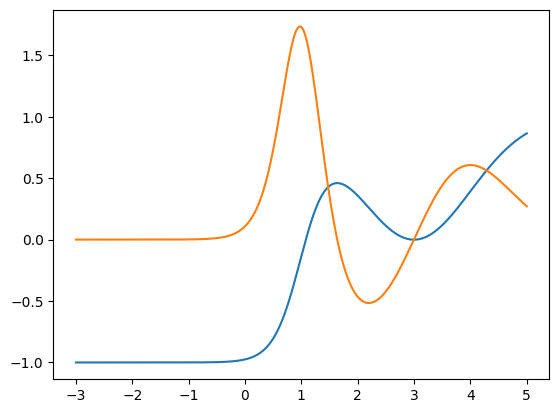

In [ ]:
plt.plot(x, f(x), label='$f(x)$')
plt.plot(x, df(x), label="$f'(x)$")
# plt.plot(x, d2f(x), label="$f''(x)$")
# plt.plot(x, curvature(x), label="$\\kappa(x)$")
# plt.plot(x, monitor_slope(x, 2, 1), label="$M_f(x)$")
# plt.plot(x, monitor_slope(x, 1, 2), label="Arc length")
# plt.plot(x, monitor_curvature(x, 2), label="$M_\\kappa(x)$")
plt.plot(x, , ls='dashed', c='black')
plt.legend()
plt.grid()
plt.show()

In [83]:
trapezoid(df(x), x), f(5) - f(-3)

(1.8646621121114484, 1.8646642818527188)

In [118]:
def adaptive_samples(a, b, N, monitor, dx):

    x_arr = np.arange(a, b+dx, dx)

    samples = []
    samples.append(a)

    mon_int = trapezoid(monitor(x_arr), x_arr)

    ia, xa = 0, samples[0]
    for i, x in enumerate(x_arr[1:]):
        interval_int = trapezoid(monitor(x_arr[ia:i]), x_arr[ia:i])
        if np.isclose(interval_int, mon_int/N, 3*dx):
            ia, xa = i, x
            samples.append(xa)
    samples.append(b)
    return np.array(samples)

In [125]:
mon = lambda x: monitor_curvature(x, 2)

samples = adaptive_samples(-3, 5, 20, mon, 1.e-3)

In [126]:
samples, len(samples)

(array([-3.   , -2.257, -1.515, -0.78 , -0.145,  0.214,  0.439,  0.675,
         1.148,  1.39 ,  1.525,  1.655,  1.841,  2.285,  2.684,  2.955,
         3.21 ,  3.525,  4.059,  4.588,  5.   ]),
 21)

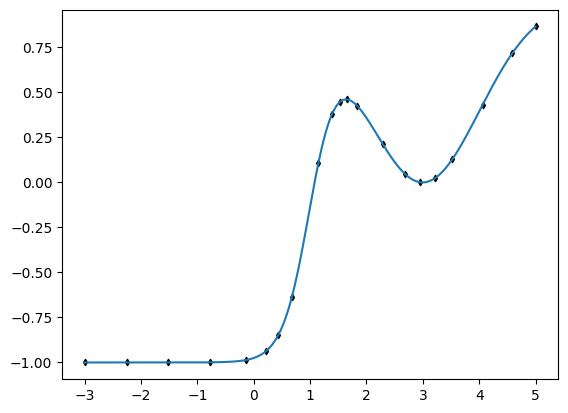

In [127]:
plt.plot(x, f(x))
plt.scatter(samples, f(samples), s=10, c='black', marker='d')

This works... sometimes, let's see Gemini's suggestion:

In [128]:
def equidistribute_mesh(x_old, monitor_func, n_points):
    xi = np.linspace(0.0, 1.0, n_points)
    M = monitor_func(x_old)
    dx = np.diff(x_old)
    m_mid = 0.5 * (M[:-1] + M[1:])
    cumulative = np.concatenate(([0.0], np.cumsum(m_mid * dx)))
    total_integral = cumulative[-1]
    s_norm = cumulative / total_integral
    x_new = np.interp(xi, s_norm, x_old)
    return x_new


In [156]:
mon = lambda x: monitor_curvature(x, 2)
# mon = lambda x: monitor_slope(x, 2, 2)
samples_gemini = equidistribute_mesh(x, mon, 30)

In [157]:
samples_gemini

array([-3.        , -2.48787559, -1.97579766, -1.46401613, -0.95471596,
       -0.46728427, -0.08022425,  0.16590767,  0.33488486,  0.47987618,
        0.64212002,  0.90945568,  1.23657723,  1.38086836,  1.47801973,
        1.56345437,  1.65449533,  1.77058519,  1.95345602,  2.32289939,
        2.60608562,  2.81029958,  2.98712292,  3.16154594,  3.35616053,
        3.60399127,  3.97866633,  4.3889363 ,  4.70544795,  5.        ])

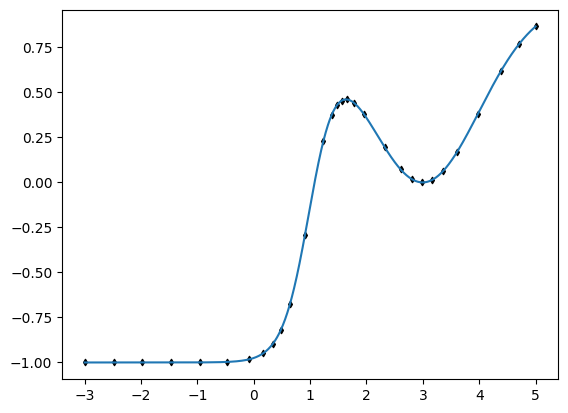

In [158]:
plt.plot(x, f(x))
plt.scatter(samples_gemini, f(samples_gemini), s=10, c='black', marker='d')